# Data Exploration


In [16]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [17]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from src.common import mpl_apply

In [18]:
df = pd.read_csv("../data/climate-daily-complete.csv")
df.head()

,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,LOCAL_DATE_dt,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,MEAN_TEMPERATURE,MIN_TEMPERATURE,MAX_TEMPERATURE,TOTAL_PRECIPITATION,TOTAL_RAIN,TOTAL_SNOW,SNOW_ON_GROUND,COOLING_DEGREE_DAYS,HEATING_DEGREE_DAYS
0,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605.0,8403605.2000.3.1,2000-03-01 00:00:00,2000-03-01,NL,2000.0,3.0,1.0,1.600000,0.600000,2.600000,0.900000,0.799873,0.40011,14.430722,0.0,16.400000
1,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605.0,8403605.2000.3.2,2000-03-02 00:00:00,2000-03-02,NL,2000.0,3.0,2.0,3.800000,0.100000,7.500000,4.700000,3.559934,0.00000,17.691577,0.0,14.200000
2,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605.0,8403605.2000.3.3,2000-03-03 00:00:00,2000-03-03,NL,2000.0,3.0,3.0,4.496255,1.200000,8.146358,2.279649,3.120332,0.00000,0.334103,0.0,13.503745
3,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605.0,8403605.2000.3.4,2000-03-04 00:00:00,2000-03-04,NL,2000.0,3.0,4.0,1.956399,-1.901247,5.823617,3.161404,3.920056,0.00000,89.452145,0.0,16.043601
4,-52.784722,47.515556,ST JOHN'S WEST CDA CS,8403605.0,8403605.2000.3.5,2000-03-05 00:00:00,2000-03-05,NL,2000.0,3.0,5.0,0.429434,-3.044891,3.919118,2.179427,3.460007,0.39999,48.424753,0.0,17.570566


In [19]:
df = df.sort_values('LOCAL_DATE_dt')

In [20]:
df.STATION_NAME.unique()

array(['LOGY BAY', 'SIGNAL HILL', "ST JOHN'S WEST CDA CS",
       'ST JOHNS WEST CLIMATE'], dtype=object)

In [21]:
mpl_apply()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Create datetime from year/month/day
df['date'] = pd.to_datetime(df[['LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY']].rename(columns={
    'LOCAL_YEAR': 'year',
    'LOCAL_MONTH': 'month',
    'LOCAL_DAY': 'day'
}))

# Sort by date
df = df.sort_values('date')

In [23]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'LOCAL_DATE_dt', 'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH',
       'LOCAL_DAY', 'MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE',
       'TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW', 'SNOW_ON_GROUND',
       'COOLING_DEGREE_DAYS', 'HEATING_DEGREE_DAYS', 'date'],
      dtype='object')

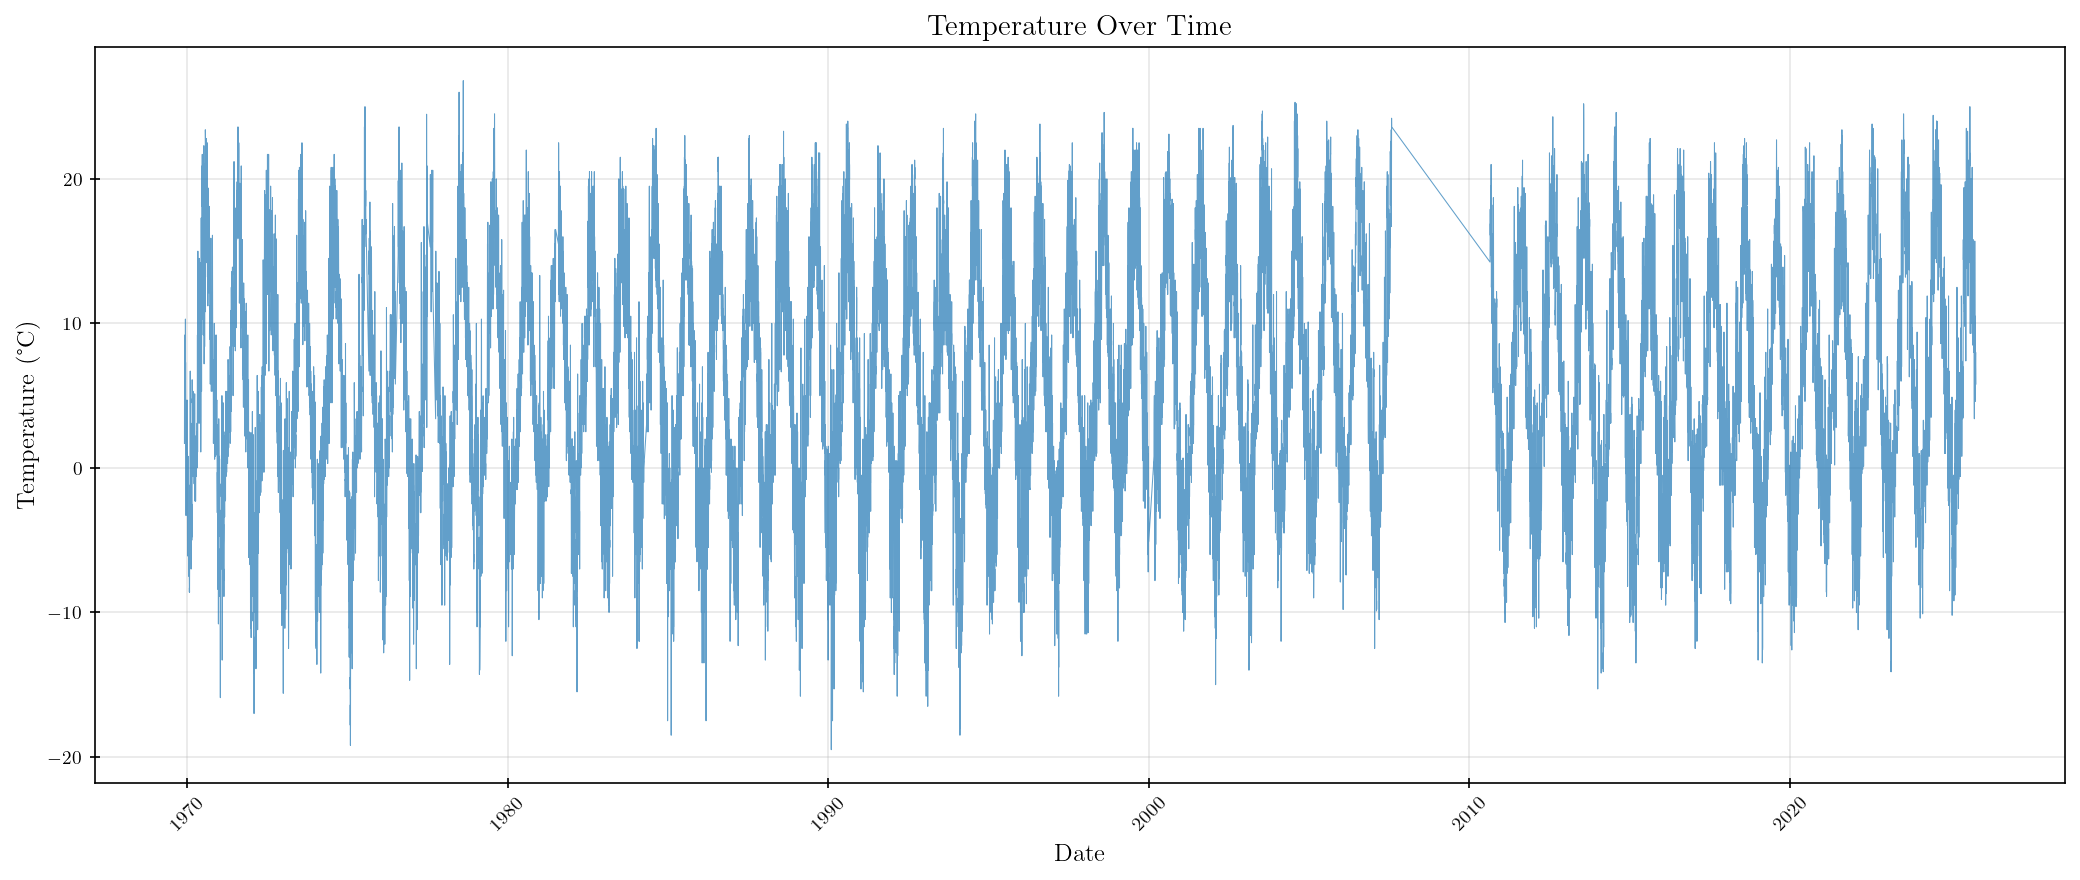

In [24]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['MEAN_TEMPERATURE'], linewidth=0.5, alpha=0.7)
plt.title('Temperature Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

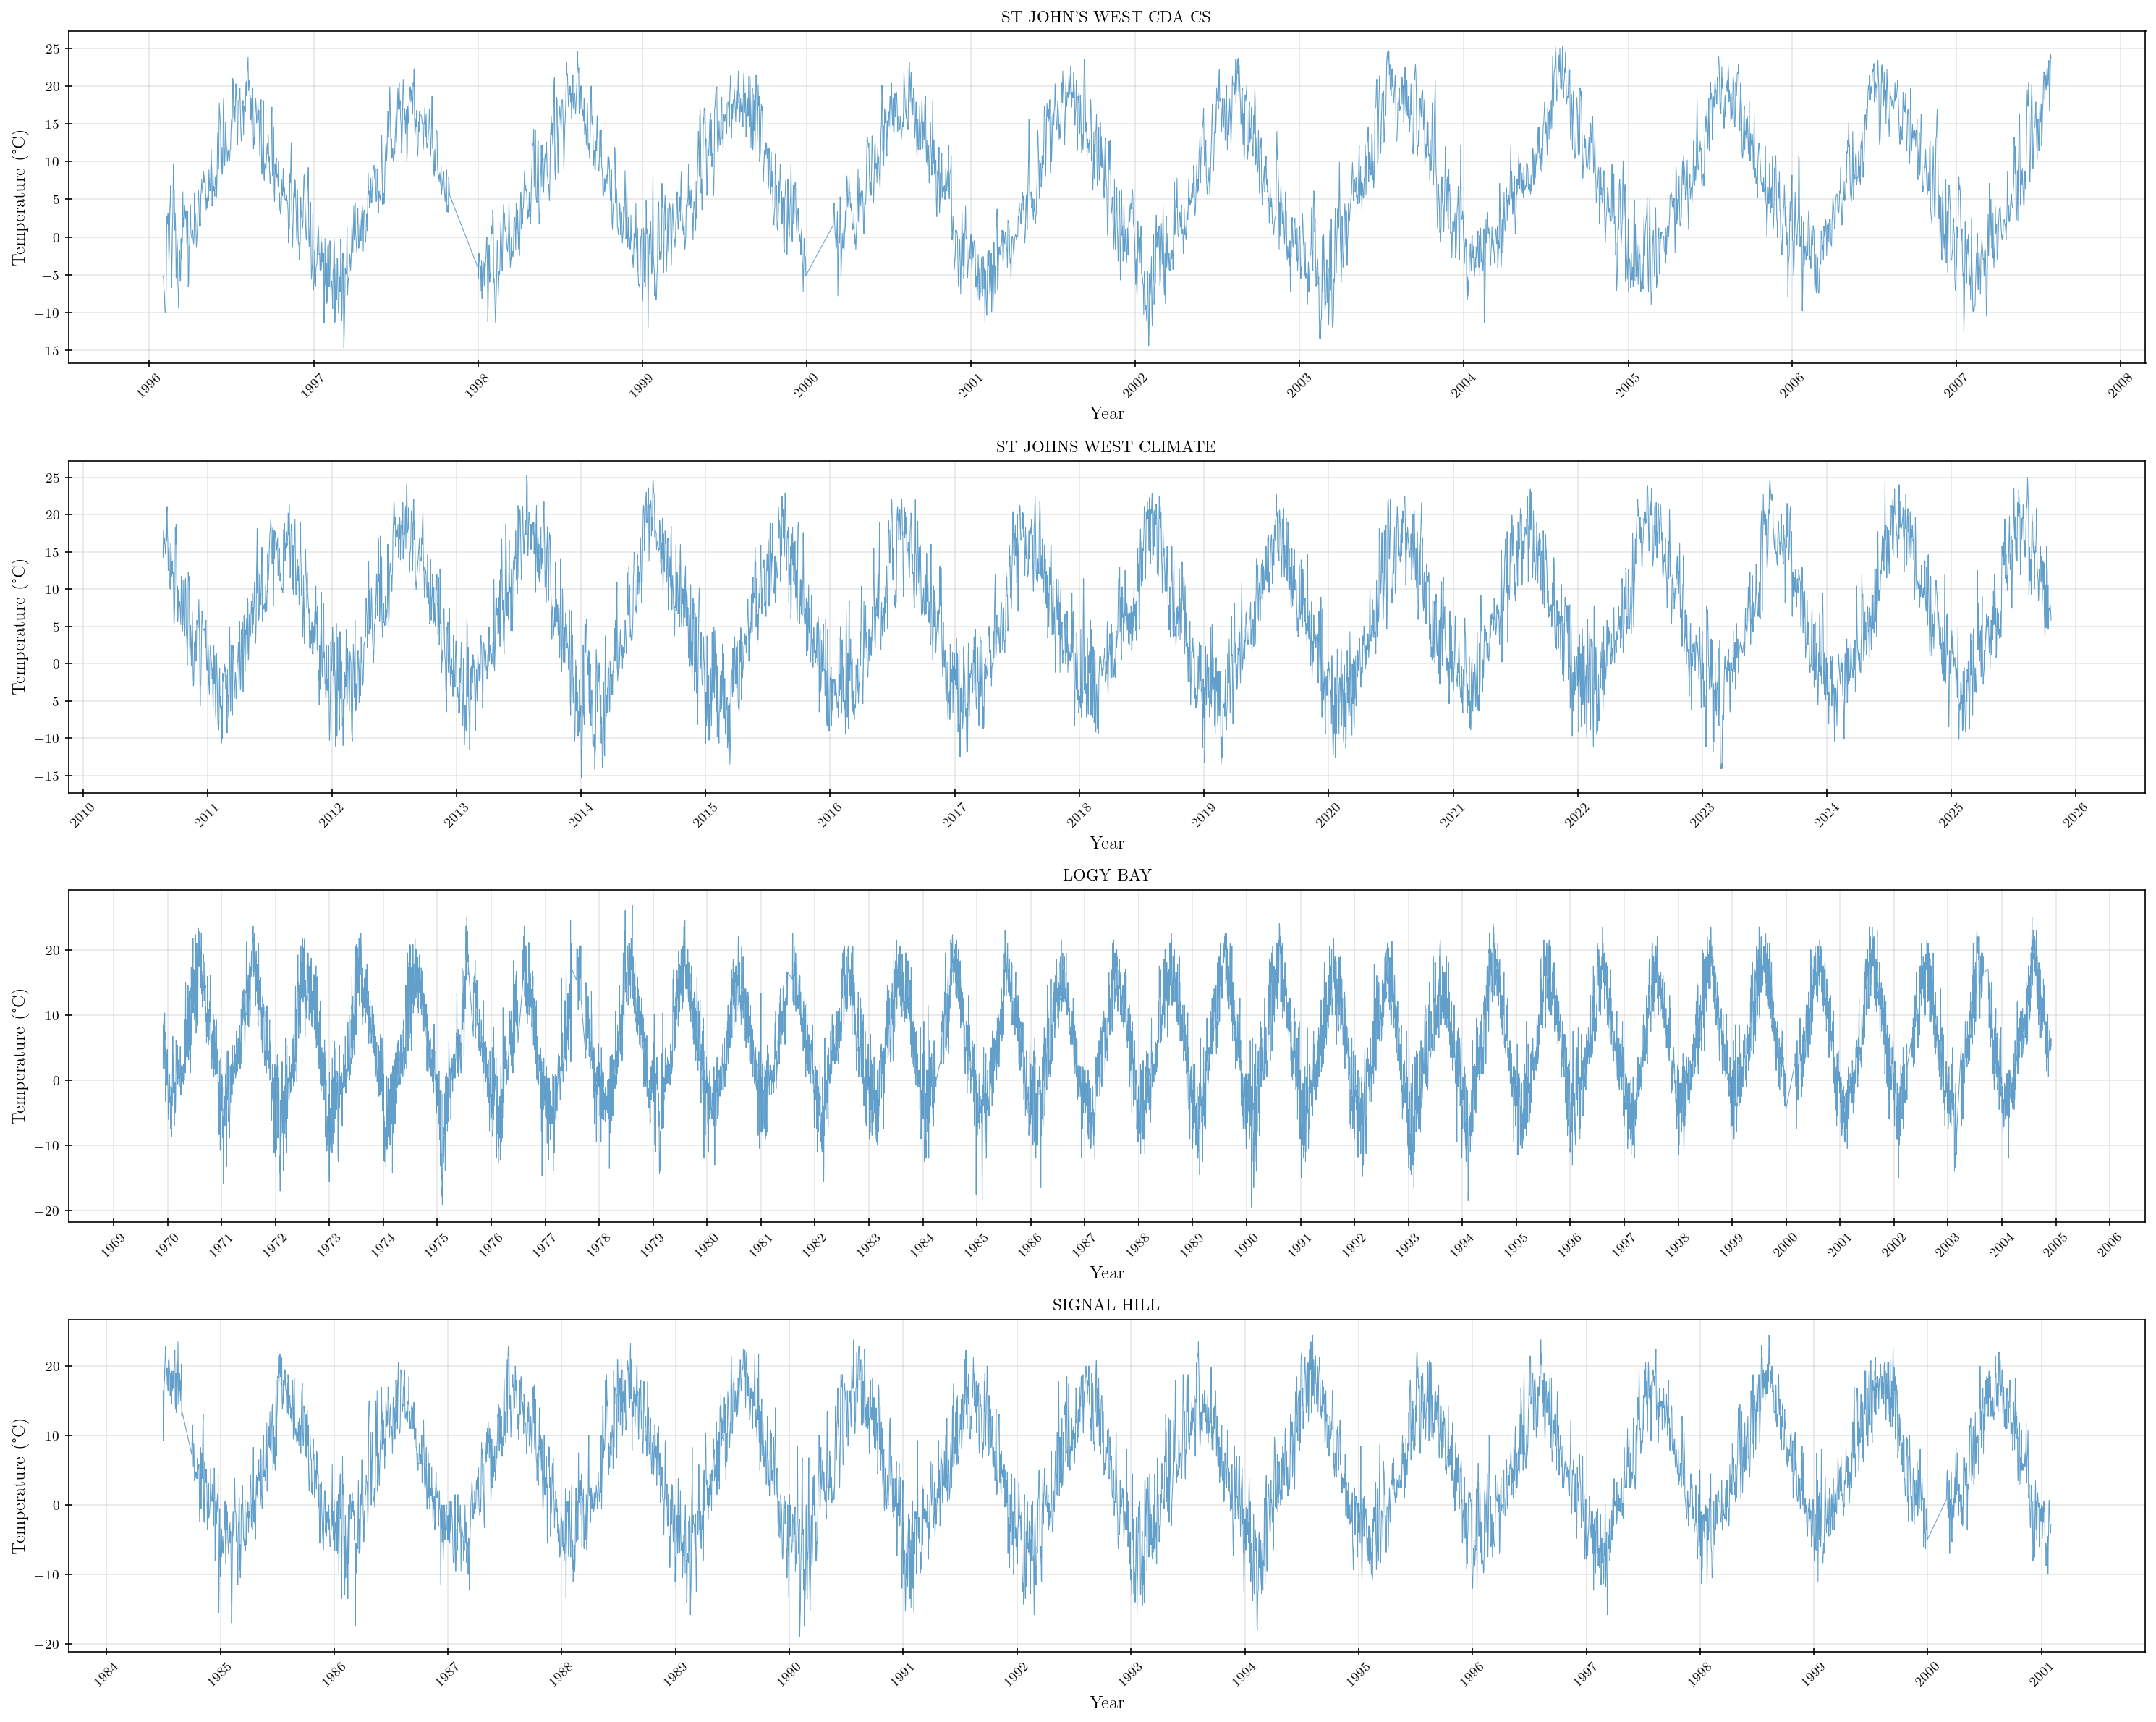

In [25]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 1, figsize=(20, 16))
stations = ["ST JOHN'S WEST CDA CS",
            'ST JOHNS WEST CLIMATE',
            'LOGY BAY',
            'SIGNAL HILL']

for ax, station in zip(axes, stations):  # Use axes, not axes.flat
    station_data = df[df['STATION_NAME'] == station]
    ax.plot(station_data['date'], station_data['MEAN_TEMPERATURE'], linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title(station)
    
    ax.xaxis.set_major_locator(mdates.YearLocator(1))  # Every 1 year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()

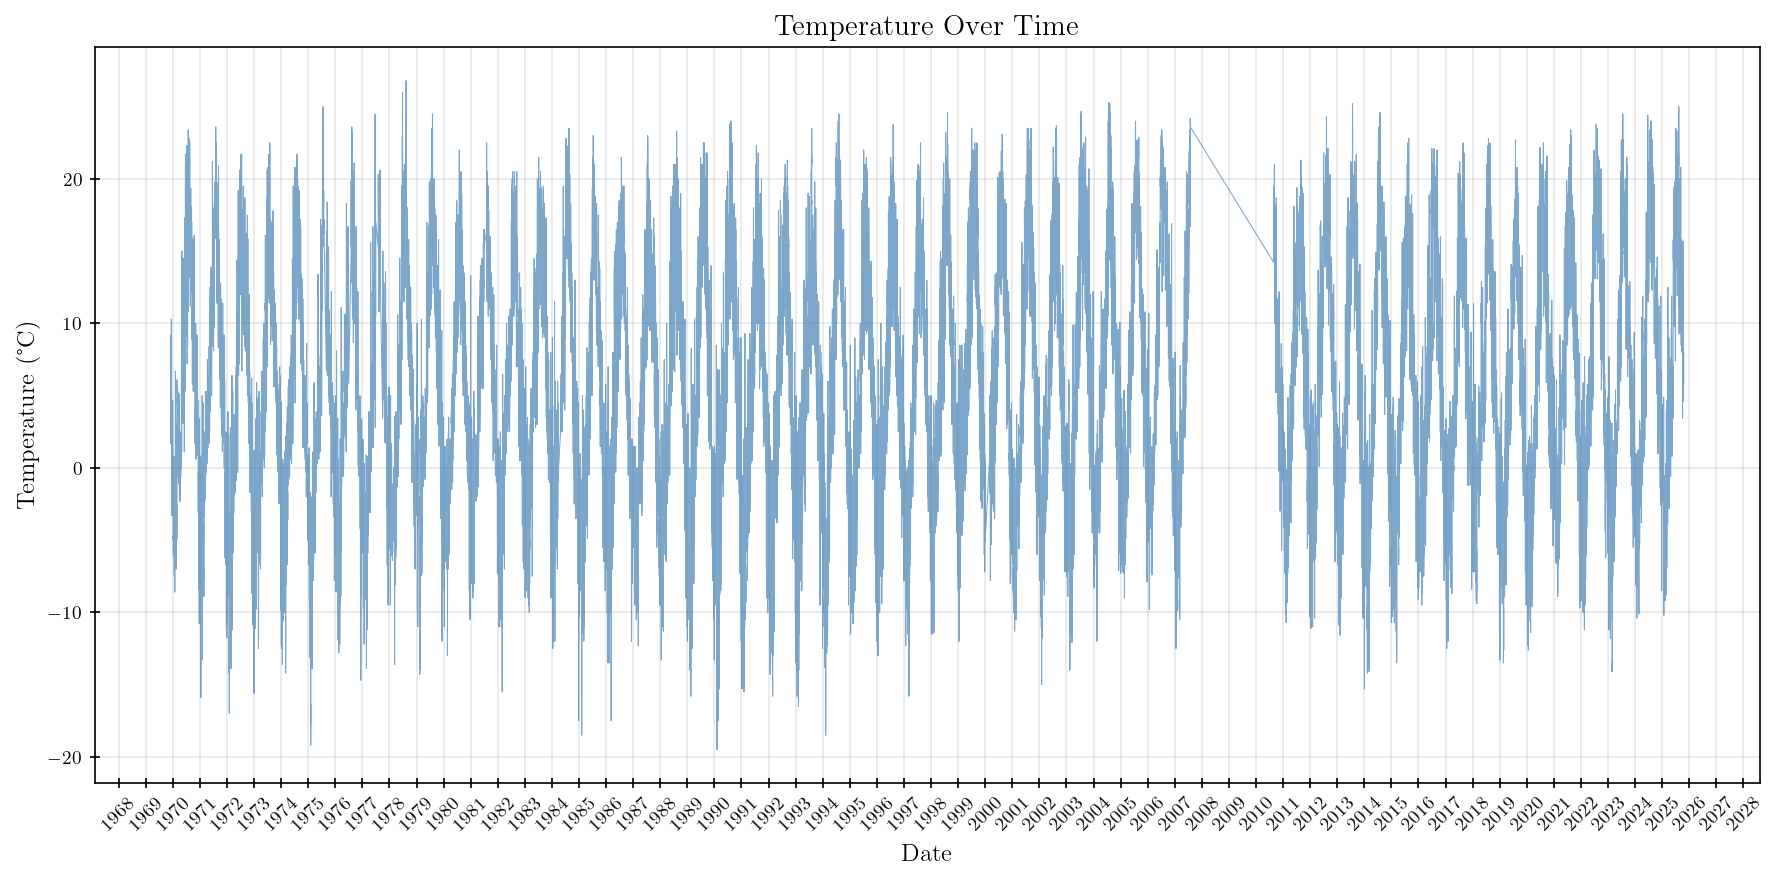

<Figure size 960x720 with 0 Axes>

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['date'], df['MEAN_TEMPERATURE'], linewidth=0.5, alpha=0.7, color='steelblue')

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("../plots/mean_temp_over_time.png", dpi=300)